In [25]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from pathlib import Path
import pandas as pd
import os

# Caminhos
PROCESSED_DIR = Path("../../data/Airbnb Prices in European Cities/processed/")

train_path = PROCESSED_DIR / "barcelona_treino.csv"
test_path = PROCESSED_DIR / "barcelona_teste.csv"


df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


print(df_train.shape, df_test.shape)

(2266, 14) (567, 14)


In [27]:
TARGET = "realSum"


X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]


X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

In [28]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

def analise_hiperparametros(features, target):

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor())
    ])

    search_space = {
        "knn__n_neighbors": Integer(3, 50),
        "knn__weights": Categorical(["uniform", "distance"]),
        "knn__metric": Categorical(["euclidean", "manhattan", "chebyshev"])
    }

    opt = BayesSearchCV(
        estimator=pipeline,
        search_spaces=search_space,
        n_iter=25,
        cv=5,
        scoring="neg_mean_squared_error",  
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    opt.fit(features, target)
    return opt


Treinamento com K-Fold

In [29]:
grid = analise_hiperparametros(X_train, y_train)

best_model = grid.best_estimator_

print("Melhores hiperparâmetros:")
print(grid.best_params_)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

Predição no conjunto de teste

In [30]:
y_pred = best_model.predict(X_test)

Avaliação do modelo (Métricas)

In [31]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MSE : 0.0052
RMSE: 0.0724
R²  : 0.6620


Feature Importance MSE

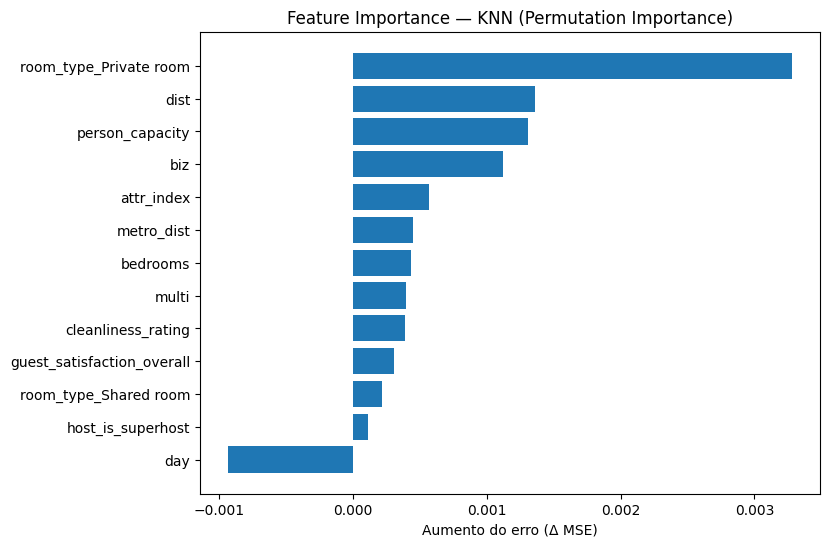

In [32]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

result = permutation_importance(
    best_model,         
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"][:15][::-1],
    importance_df["importance"][:15][::-1]
)
plt.xlabel("Aumento do erro (Δ MSE)")
plt.title("Feature Importance — KNN (Permutation Importance)")
plt.show()



Feature Importance R²

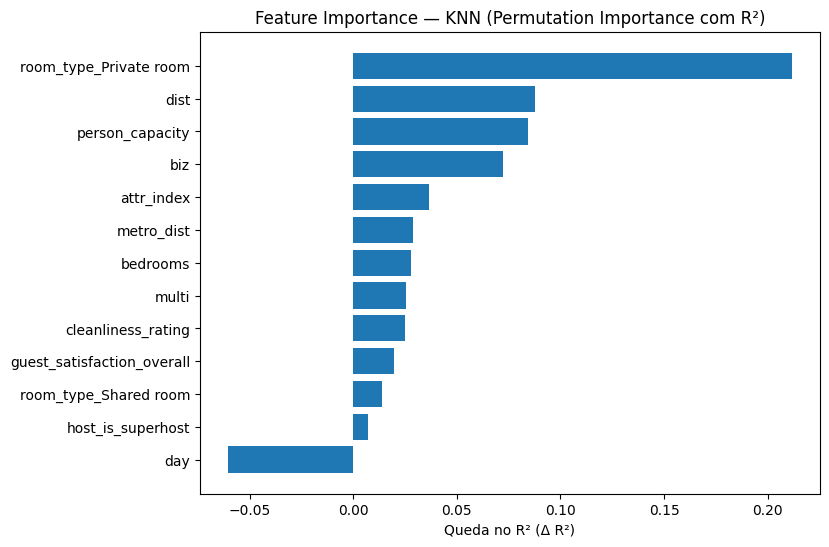

In [33]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"][:15][::-1],
    importance_df["importance"][:15][::-1]
)
plt.xlabel("Queda no R² (Δ R²)")
plt.title("Feature Importance — KNN (Permutation Importance com R²)")
plt.show()
